In [ ]:
SPAM MAIL DETECTION USING MACHINE LEARNING IN PYTHON

In [3]:
import pandas as pd 
import numpy as np

In [2]:
df=pd.read_csv("spam.csv",encoding='ISO-8859-1')

In [3]:
df.head()

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,ham,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   v1          5572 non-null   object
 1   v2          5572 non-null   object
 2   Unnamed: 2  50 non-null     object
 3   Unnamed: 3  12 non-null     object
 4   Unnamed: 4  6 non-null      object
dtypes: object(5)
memory usage: 217.8+ KB


In [5]:
df.isna().sum()

v1               0
v2               0
Unnamed: 2    5522
Unnamed: 3    5560
Unnamed: 4    5566
dtype: int64

In [6]:
df.drop(columns=['Unnamed: 2','Unnamed: 3','Unnamed: 4'],inplace=True)

In [7]:
df

,v1,v2
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."
...,...,...
5567,spam,This is the 2nd time we have tried 2 contact u...
5568,ham,Will Ì_ b going to esplanade fr home?
5569,ham,"Pity, * was in mood for that. So...any other s..."
5570,ham,The guy did some bitching but I acted like i'd...


In [8]:
df.rename(columns={'v1':'target','v2':'text'},inplace=True)

In [9]:
df

,target,text
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."
...,...,...
5567,spam,This is the 2nd time we have tried 2 contact u...
5568,ham,Will Ì_ b going to esplanade fr home?
5569,ham,"Pity, * was in mood for that. So...any other s..."
5570,ham,The guy did some bitching but I acted like i'd...


In [10]:
from sklearn.preprocessing import LabelEncoder
encoder=LabelEncoder()

In [11]:
df['target']=encoder.fit_transform(df['target'])

In [12]:
df

,target,text
0,0,"Go until jurong point, crazy.. Available only ..."
1,0,Ok lar... Joking wif u oni...
2,1,Free entry in 2 a wkly comp to win FA Cup fina...
3,0,U dun say so early hor... U c already then say...
4,0,"Nah I don't think he goes to usf, he lives aro..."
...,...,...
5567,1,This is the 2nd time we have tried 2 contact u...
5568,0,Will Ì_ b going to esplanade fr home?
5569,0,"Pity, * was in mood for that. So...any other s..."
5570,0,The guy did some bitching but I acted like i'd...


In [13]:
df.isnull().sum()

target    0
text      0
dtype: int64

In [14]:
df.duplicated().sum()

403

In [15]:
 df=df.drop_duplicates(keep='first')

In [16]:
df.duplicated().sum()

0

In [17]:
df.shape

(5169, 2)

In [18]:
 #eda

In [19]:
df.head()

,target,text
0,0,"Go until jurong point, crazy.. Available only ..."
1,0,Ok lar... Joking wif u oni...
2,1,Free entry in 2 a wkly comp to win FA Cup fina...
3,0,U dun say so early hor... U c already then say...
4,0,"Nah I don't think he goes to usf, he lives aro..."


In [20]:
df['target'].value_counts()

target
0    4516
1     653
Name: count, dtype: int64

In [21]:
import matplotlib.pyplot as plt

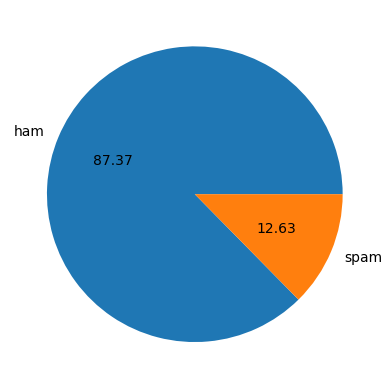

In [22]:
plt.pie(df['target'].value_counts(),labels=['ham','spam'],autopct='%0.2f')
plt.show()

In [23]:
#data is imbalaced

In [24]:
import nltk

In [25]:
nltk.download('punkt')

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\USER\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!


True

In [26]:
df['num_char']=df['text'].apply(len)

C:\Users\USER\AppData\Local\Temp\ipykernel_16144\1162800108.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['num_char']=df['text'].apply(len)


In [27]:
df.head()

,target,text,num_char
0,0,"Go until jurong point, crazy.. Available only ...",111
1,0,Ok lar... Joking wif u oni...,29
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155
3,0,U dun say so early hor... U c already then say...,49
4,0,"Nah I don't think he goes to usf, he lives aro...",61


In [28]:
df['num_word']=df['text'].apply(lambda x:len(nltk.word_tokenize(x)))

C:\Users\USER\AppData\Local\Temp\ipykernel_16144\3335927336.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['num_word']=df['text'].apply(lambda x:len(nltk.word_tokenize(x)))


In [29]:
df

,target,text,num_char,num_word
0,0,"Go until jurong point, crazy.. Available only ...",111,24
1,0,Ok lar... Joking wif u oni...,29,8
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,37
3,0,U dun say so early hor... U c already then say...,49,13
4,0,"Nah I don't think he goes to usf, he lives aro...",61,15
...,...,...,...,...
5567,1,This is the 2nd time we have tried 2 contact u...,161,35
5568,0,Will Ì_ b going to esplanade fr home?,37,9
5569,0,"Pity, * was in mood for that. So...any other s...",57,15
5570,0,The guy did some bitching but I acted like i'd...,125,27


In [30]:
df['num_sentence']=df['text'].apply(lambda x:len(nltk.sent_tokenize(x)))

C:\Users\USER\AppData\Local\Temp\ipykernel_16144\3985788005.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['num_sentence']=df['text'].apply(lambda x:len(nltk.sent_tokenize(x)))


In [31]:
df

,target,text,num_char,num_word,num_sentence
0,0,"Go until jurong point, crazy.. Available only ...",111,24,2
1,0,Ok lar... Joking wif u oni...,29,8,2
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,37,2
3,0,U dun say so early hor... U c already then say...,49,13,1
4,0,"Nah I don't think he goes to usf, he lives aro...",61,15,1
...,...,...,...,...,...
5567,1,This is the 2nd time we have tried 2 contact u...,161,35,4
5568,0,Will Ì_ b going to esplanade fr home?,37,9,1
5569,0,"Pity, * was in mood for that. So...any other s...",57,15,2
5570,0,The guy did some bitching but I acted like i'd...,125,27,1


In [32]:
df[['num_char','num_word','num_sentence']].describe()

,num_char,num_word,num_sentence
count,5169.000000,5169.000000,5169.000000
mean,78.977945,18.455794,1.965564
std,58.236293,13.324758,1.448541
min,2.000000,1.000000,1.000000
25%,36.000000,9.000000,1.000000
50%,60.000000,15.000000,1.000000
75%,117.000000,26.000000,2.000000
max,910.000000,220.000000,38.000000


In [33]:
df[df['target']==0][['num_char','num_word','num_sentence']].describe()

,num_char,num_word,num_sentence
count,4516.000000,4516.000000,4516.000000
mean,70.459256,17.123782,1.820195
std,56.358207,13.493970,1.383657
min,2.000000,1.000000,1.000000
25%,34.000000,8.000000,1.000000
50%,52.000000,13.000000,1.000000
75%,90.000000,22.000000,2.000000
max,910.000000,220.000000,38.000000


In [34]:
df[df['target']==1][['num_char','num_word','num_sentence']].describe()

,num_char,num_word,num_sentence
count,653.000000,653.000000,653.000000
mean,137.891271,27.667688,2.970904
std,30.137753,7.008418,1.488425
min,13.000000,2.000000,1.000000
25%,132.000000,25.000000,2.000000
50%,149.000000,29.000000,3.000000
75%,157.000000,32.000000,4.000000
max,224.000000,46.000000,9.000000


In [35]:
import seaborn as sns

<Axes: xlabel='num_char', ylabel='Count'>

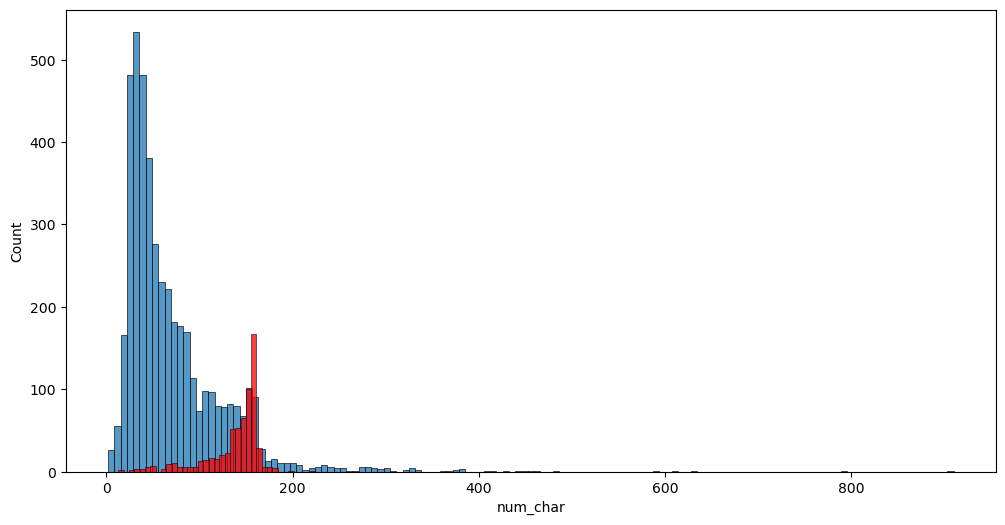

In [36]:
plt.figure(figsize=(12,6))
sns.histplot(df[df['target']==0]['num_char'])
sns.histplot(df[df['target']==1]['num_char'],color='red')

<Axes: xlabel='num_word', ylabel='Count'>

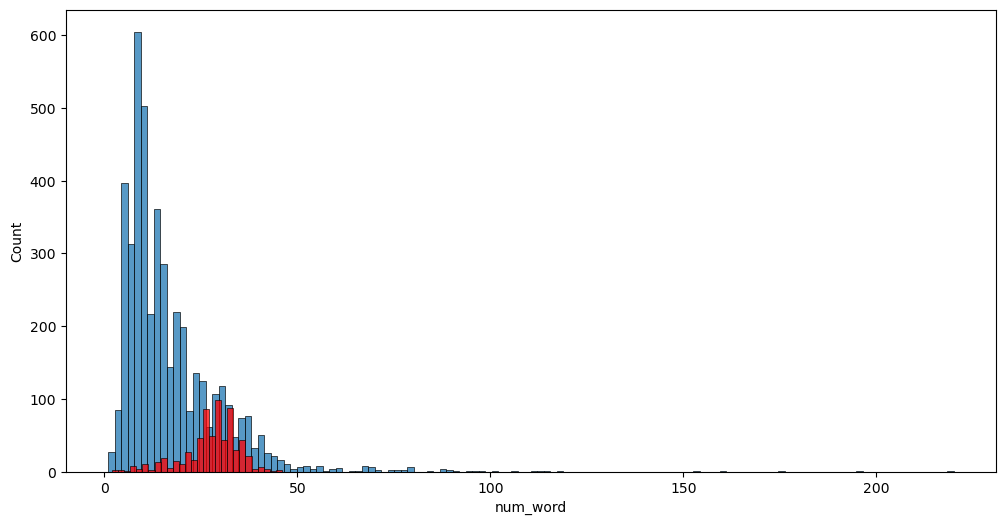

In [37]:
plt.figure(figsize=(12,6))
sns.histplot(df[df['target']==0]['num_word'])
sns.histplot(df[df['target']==1]['num_word'],color='red')

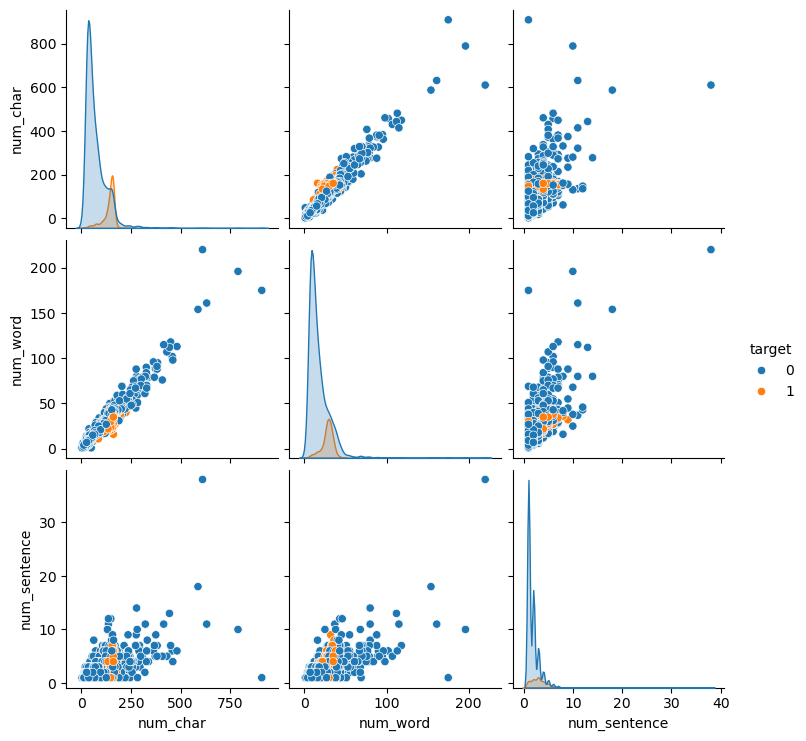

In [38]:
sns.pairplot(df,hue='target')

<Axes: >

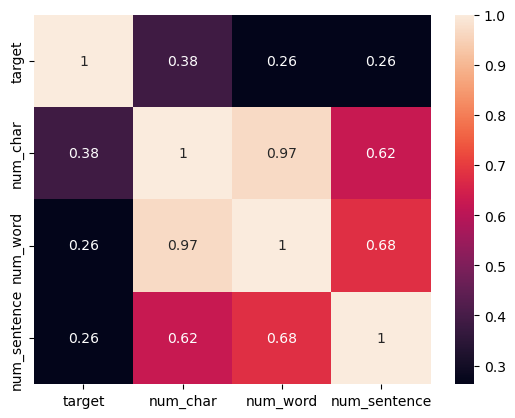

In [39]:
sns.heatmap(df.corr(numeric_only=True),annot=True)

In [40]:
from sklearn.feature_extraction.text import TfidfVectorizer
import re
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier, GradientBoostingClassifier
from xgboost import XGBClassifier
from sklearn.model_selection import RandomizedSearchCV

In [41]:
def wordopt(text):
    #convert into lowercase
    text=text.lower()
    #remove URLs
    text=re.sub(r'https?://\S+|www\.\S+','',text)
    #remove HTML Tags
    text=re.sub(r'<.*?>','',text)
    #remove punctution
    text=re.sub(r'[^\w\s]','',text)
    #remove digits
    text=re.sub(r'\d','',text)
    #remove newline characters
    text=re.sub(r'\n','',text)
    return text

In [42]:
df['text']=df['text'].apply(wordopt)

C:\Users\USER\AppData\Local\Temp\ipykernel_16144\699996257.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['text']=df['text'].apply(wordopt)


In [43]:
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.feature_extraction.text import TfidfVectorizer

In [44]:
tfidf=TfidfVectorizer()

In [45]:
X= tfidf.fit_transform(df['text']).toarray()

In [46]:
y = df['target'].values

In [47]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [48]:
models={
    'LogisticRegression':LogisticRegression(),
    'RandomForestClassifier':RandomForestClassifier(),
    'DecisionTreeClassifier':DecisionTreeClassifier(),
    'KNeighborsClassifier':KNeighborsClassifier(),
    'SVC':SVC(),
    'AdaBoostClassifier':AdaBoostClassifier(),
    'GradientBoostingClassifier':GradientBoostingClassifier()
}

In [49]:
results={}
for name,model in models.items():
    model.fit(X_train,y_train)
    y_train_pred=model.predict(X_train)
    y_test_pred=model.predict(X_test)
    results[name] = {
        'train_accuracy': accuracy_score(y_train, y_train_pred),
        'test_accuracy': accuracy_score(y_test, y_test_pred),
        'train_confusion_matrix': confusion_matrix(y_train, y_train_pred),
        'test_confusion_matrix': confusion_matrix(y_test, y_test_pred),
        'train_classification_report': classification_report(y_train, y_train_pred),
        'test_classification_report': classification_report(y_test, y_test_pred)
    }

C:\Users\USER\AppData\Roaming\Python\Python312\site-packages\sklearn\ensemble\_weight_boosting.py:527: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(


In [50]:
for model_name, metrics in results.items():
    print(f"\nModel: {model_name}")
    print(f"Train Accuracy: {metrics['train_accuracy']:.4f}")
    print(f"Test Accuracy: {metrics['test_accuracy']:.4f}")
    print("\nTrain Confusion Matrix:")
    print(metrics['train_confusion_matrix'])
    print("\nTest Confusion Matrix:")
    print(metrics['test_confusion_matrix'])
    print("\nTrain Classification Report:")
    print(metrics['train_classification_report'])
    print("\nTest Classification Report:")
    print(metrics['test_classification_report'])
    print("=" * 60)


Model: LogisticRegression
Train Accuracy: 0.9688
Test Accuracy: 0.9497

Train Confusion Matrix:
[[3625    2]
 [ 127  381]]

Test Confusion Matrix:
[[886   3]
 [ 49  96]]

Train Classification Report:
              precision    recall  f1-score   support

           0       0.97      1.00      0.98      3627
           1       0.99      0.75      0.86       508

    accuracy                           0.97      4135
   macro avg       0.98      0.87      0.92      4135
weighted avg       0.97      0.97      0.97      4135


Test Classification Report:
              precision    recall  f1-score   support

           0       0.95      1.00      0.97       889
           1       0.97      0.66      0.79       145

    accuracy                           0.95      1034
   macro avg       0.96      0.83      0.88      1034
weighted avg       0.95      0.95      0.95      1034


Model: RandomForestClassifier
Train Accuracy: 1.0000
Test Accuracy: 0.9671

Train Confusion Matrix:
[[3627    0]
 [

In [52]:
from sklearn.model_selection import GridSearchCV
from sklearn.svm import SVC
param_grid = {
    'C': [0.1, 1, 10, 100],
    'kernel': ['linear', 'rbf', 'poly', 'sigmoid'],
    'gamma': ['scale', 'auto']
}
grid_svc = GridSearchCV(SVC(), param_grid, cv=5, scoring='accuracy', n_jobs=-1)
grid_svc.fit(X_train, y_train)
print("Best Parameters:", grid_svc.best_params_)
print("Best Cross-Validated Score:", grid_svc.best_score_)


Best Parameters: {'C': 1, 'gamma': 'scale', 'kernel': 'linear'}
Best Cross-Validated Score: 0.9779927448609431


In [54]:
import pickle
pickle.dump(tfidf, open('vectorizer.pkl', 'wb'))
pickle.dump(SVC, open('model.pkl', 'wb'))

In [2]:
import pandas as pd
import numpy as np
import re
import nltk
from sklearn.preprocessing import LabelEncoder
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split,GridSearchCV
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier,AdaBoostClassifier,GradientBoostingClassifier
from nltk.stem.porter import PorterStemmer
from nltk.corpus import stopwords
import pickle
# Download NLTK data
nltk.download('punkt')
nltk.download('stopwords')
# Initialize stemmer
port_stem=PorterStemmer()
def load_data(filepath):
    data=pd.read_csv(filepath,encoding='ISO-8859-1')
    data.drop(columns=['Unnamed: 2','Unnamed: 3','Unnamed: 4'],inplace=True)
    data.rename(columns={'v1':'target','v2':'text'},inplace=True)
    return data
def stemming(content):
    stemmed_content=content.lower()
    stemmed_content=stemmed_content.split()
    stemmed_content=[port_stem.stem(word) for word in stemmed_content if word not in stopwords.words('english')]
    stemmed_content=' '.join(stemmed_content)
    return stemmed_content
def add_text_features(data):
    data['num_char']=data['text'].apply(len)
    data['num_word']=data['text'].apply(lambda x:len(nltk.word_tokenize(x)))
    data['num_sentence']=data['text'].apply(lambda x:len(nltk.sent_tokenize(x)))
    return data
def main():
    # Load and preprocess data
    data=load_data("spam.csv")
    data['target']=LabelEncoder().fit_transform(data['target'])
    data=data.drop_duplicates(keep='first')
    data['text'] = data['text'].apply(stemming)
    data=add_text_features(data)
    # Split data with consistent naming
    X=data['text']
    y=data['target']
    X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2)
    models = {
        'LogisticRegression':LogisticRegression(max_iter=1000),
        'RandomForest':RandomForestClassifier(),
        'DecisionTree':DecisionTreeClassifier(),
        'KNN':KNeighborsClassifier(),
        'SVM':SVC(),
        'AdaBoost':AdaBoostClassifier(),
        'GradientBoost':GradientBoostingClassifier()
    }
    
    results={}
    tfidf=TfidfVectorizer()
    for name,model in models.items():
        pipeline=Pipeline([
            ('tfidf',tfidf),
            ('model',model)
        ])
        pipeline.fit(X_train, y_train)
        # Use consistent variable names
        y_train_pred=pipeline.predict(X_train)
        y_test_pred=pipeline.predict(X_test)  
        results[name] = {
            'train_accuracy':accuracy_score(y_train,y_train_pred),
            'test_accuracy':accuracy_score(y_test,y_test_pred),  
            'train_confusion_matrix':confusion_matrix(y_train,y_train_pred),
            'test_confusion_matrix':confusion_matrix(y_test,y_test_pred),  # Fixed variable name
            'train_classification_report':classification_report(y_train,y_train_pred),
            'test_classification_report':classification_report(y_test,y_test_pred)  # Fixed variable name
        }
    
    for model_name,metrics in results.items():
        print(f"\nModel:{model_name}")
        print(f"Train Accuracy:{metrics['train_accuracy']:.4f}")
        print(f"Test Accuracy:{metrics['test_accuracy']:.4f}")
        print("\nTest Classification Report:")
        print(metrics['test_classification_report'])
        print("=" * 60)
    
    # Hyperparameter tuning
    param_grid = {
        'tfidf__max_features':[1000,2000,5000],
        'tfidf__ngram_range':[(1,1),(1,2)],
        'model__C':[0.1,1,10],
        'model__kernel':['linear','rbf'],
        'model__gamma':['scale','auto']
    }
    svm_pipeline = Pipeline([
        ('tfidf',TfidfVectorizer()),
        ('model',SVC())
    ])
    grid_search = GridSearchCV(svm_pipeline,param_grid,cv=5,scoring='accuracy',n_jobs=-1)
    grid_search.fit(X_train,y_train)
    print("\nBest Parameters:",grid_search.best_params_)
    print("Best Cross-Validated Score:",grid_search.best_score_)
    best_model=grid_search.best_estimator_
    y_test_pred=best_model.predict(X_test)
    print("\nBest Model Test Accuracy:",accuracy_score(y_test,y_test_pred))
    print("\nBest Model Test Classification Report:")
    print(classification_report(y_test,y_test_pred))
    print("\nSaving models to disk...")
    # 1. Save the best model
    with open('best_spam_classifier.pkl', 'wb') as f:
        pickle.dump(best_model, f)
    # 2. Save the TF-IDF vectorizer with best parameters
    best_tfidf = TfidfVectorizer(
        max_features=grid_search.best_params_['tfidf__max_features'],
        ngram_range=grid_search.best_params_['tfidf__ngram_range']
    )
    best_tfidf.fit(X_train)
    with open('best_tfidf_vectorizer.pkl', 'wb') as f:
        pickle.dump(best_tfidf, f)
    print("Models saved successfully!")
if __name__ == "__main__":
    main()

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\USER\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\USER\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
C:\Users\USER\AppData\Roaming\Python\Python312\site-packages\sklearn\ensemble\_weight_boosting.py:527: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(



Model:LogisticRegression
Train Accuracy:0.9669
Test Accuracy:0.9652

Test Classification Report:
              precision    recall  f1-score   support

           0       0.96      1.00      0.98       924
           1       0.97      0.69      0.81       110

    accuracy                           0.97      1034
   macro avg       0.97      0.84      0.89      1034
weighted avg       0.97      0.97      0.96      1034


Model:RandomForest
Train Accuracy:1.0000
Test Accuracy:0.9797

Test Classification Report:
              precision    recall  f1-score   support

           0       0.98      1.00      0.99       924
           1       0.99      0.82      0.90       110

    accuracy                           0.98      1034
   macro avg       0.98      0.91      0.94      1034
weighted avg       0.98      0.98      0.98      1034


Model:DecisionTree
Train Accuracy:1.0000
Test Accuracy:0.9642

Test Classification Report:
              precision    recall  f1-score   support

         